In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("creditcard.csv")

In [3]:
df.shape

(284807, 31)

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df = df.sample(n=20000, random_state=42)

In [7]:
df.shape

(20000, 31)

In [9]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,94499.135100,-0.017378,-0.008485,0.009056,-0.001113,-0.000380,-0.004689,-0.008022,0.001160,-0.009660,...,-0.001995,0.007521,-0.000859,0.000868,0.008984,0.001918,0.004275,-0.003042,87.071819,0.001700
std,47338.533989,2.004699,1.720016,1.526247,1.415884,1.393855,1.330286,1.230951,1.200088,1.103987,...,0.712706,0.722903,0.613808,0.606636,0.521617,0.480338,0.419697,0.341547,227.972063,0.041197
min,0.000000,-33.669917,-48.060856,-30.177317,-5.560118,-23.611865,-20.869626,-31.197329,-39.688571,-9.462573,...,-18.632919,-8.887017,-22.575000,-2.824849,-3.963454,-2.068561,-22.565679,-11.710896,0.000000,0.000000
25%,54111.000000,-0.925237,-0.598687,-0.879809,-0.850125,-0.708272,-0.769688,-0.571396,-0.209420,-0.648614,...,-0.226727,-0.537442,-0.165443,-0.352648,-0.309628,-0.323868,-0.071069,-0.053034,5.777500,0.000000
50%,84335.500000,0.006737,0.063697,0.190854,-0.029415,-0.054493,-0.269856,0.027064,0.022942,-0.056590,...,-0.026181,0.016481,-0.015446,0.044761,0.033552,-0.050475,0.000732,0.010743,21.610000,0.000000
75%,138886.250000,1.308129,0.799694,1.042387,0.742371,0.616476,0.395364,0.567894,0.324586,0.588707,...,0.185079,0.528532,0.143181,0.438865,0.353297,0.244132,0.089946,0.078607,76.385000,0.000000
max,172782.000000,2.393199,16.497472,9.382558,12.699542,29.016124,16.493227,21.437514,17.052566,15.594995,...,27.202839,8.272233,22.083545,3.546031,6.070850,2.952093,9.200883,15.649134,5239.500000,1.000000


In [10]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(5)

In [12]:
df.drop_duplicates(inplace=True)

In [14]:
df["Class"].value_counts()
# 0= Successfull Transection , 1= incomplete/Fraudulent Transection

Class
0    19961
1       34
Name: count, dtype: int64

In [18]:
import matplotlib.pyplot as plt 
import seaborn as sns


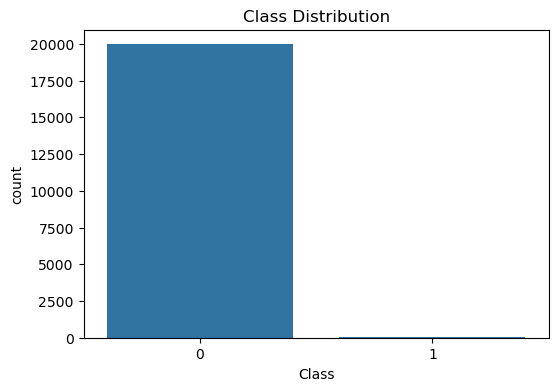

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.title("Class Distribution")
plt.show()

In [20]:
X = df.drop("Class", axis=1)

y = df["Class"]

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [23]:
scaler = StandardScaler()

X["Amount"] = scaler.fit_transform(X[["Amount"]])

X["Time"] = scaler.fit_transform(X[["Time"]])

In [24]:
# Handle Imbalanced Data
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

### Train-Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
# Apply SMOTE (Synthetic Minority Over-Sampling Technique)
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [27]:
print(y_train.value_counts())

print(y_train_smote.value_counts())

Class
0    15969
1       27
Name: count, dtype: int64
Class
0    15969
1    15969
Name: count, dtype: int64


### Train Logistic Regression

In [28]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [29]:
# Testing
y_pred_lr = lr.predict(X_test)

In [30]:
#Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred_lr))

print("Precision :", precision_score(y_test, y_pred_lr))

print("Recall :", recall_score(y_test, y_pred_lr))

print("F1 Score :", f1_score(y_test, y_pred_lr))

print("ROC AUC :", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

Accuracy : 0.9877469367341836
Precision : 0.1111111111111111
Recall : 0.8571428571428571
F1 Score : 0.19672131147540983
ROC AUC : 0.9320784425994846


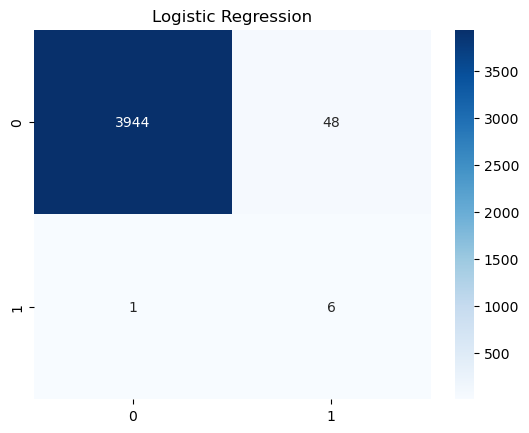

In [31]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Logistic Regression")

plt.show()

### Random Forest 

In [32]:
rf = RandomForestClassifier(
    n_estimators=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_smote, y_train_smote)

,n_estimators,20
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
# testing
y_pred_rf = rf.predict(X_test)

In [35]:
# Evaluation 
print("Accuracy :", accuracy_score(y_test, y_pred_rf))

print("Precision :", precision_score(y_test, y_pred_rf))

print("Recall :", recall_score(y_test, y_pred_rf))

print("F1 Score :", f1_score(y_test, y_pred_rf))

print("ROC AUC :", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

Accuracy : 0.9992498124531133
Precision : 0.8333333333333334
Recall : 0.7142857142857143
F1 Score : 0.7692307692307693
ROC AUC : 0.9240981963927856


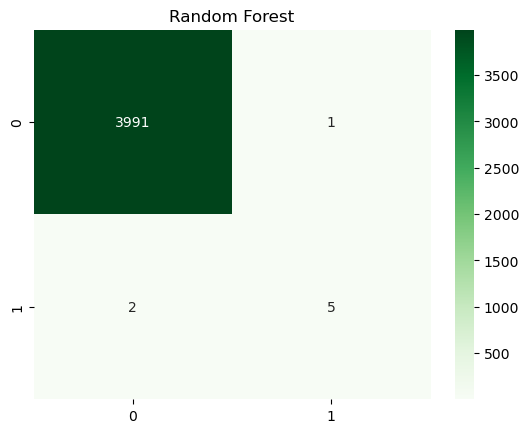

In [36]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.title("Random Forest")

plt.show()

### Compare Models

In [37]:
comparison = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest"],
    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_rf)
    ],
    "Precision":[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_rf)
    ],
    "Recall":[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_rf)
    ],
    "F1 Score":[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_rf)
    ],
    "ROC AUC":[
        roc_auc_score(y_test,lr.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test,rf.predict_proba(X_test)[:,1])
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.987747,0.111111,0.857143,0.196721,0.932078
1,Random Forest,0.999250,0.833333,0.714286,0.769231,0.924098


In [39]:
sample = X_test.iloc[[0]]

prediction = rf.predict(sample)

print("Predicted Class:", prediction[0])

print("Actual Class:", y_test.iloc[0])

if prediction[0] == 0:
    print("The transaction is Genuine.")
else:
    print("The transaction is Fraudulent.")

Predicted Class: 0
Actual Class: 0
The transaction is Genuine.


## Summary

In this project, I built a Credit Card Fraud Detection system using machine learning techniques. The dataset was explored and preprocessed by checking for missing values, duplicate records, and class imbalance. Feature scaling was applied to numerical features, and the dataset was divided into training and testing sets.

Since the dataset was highly imbalanced, SMOTE (Synthetic Minority Oversampling Technique) was applied to the training data to create a balanced dataset. Two classification models, Logistic Regression and Random Forest, were trained and tested on unseen data.

The models were evaluated using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Confusion Matrix. Finally, the trained model was used to predict whether a new transaction was fraudulent or genuine. The project demonstrated the complete machine learning pipeline, from data preprocessing to model evaluation and prediction.